In [1]:
import tensorflow as tf
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
print(tf.__version__)

2.21.0


In [4]:
(X_train,Y_train),(X_test,Y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


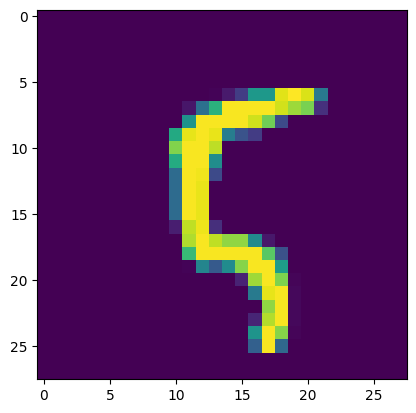

In [6]:
plt.imshow(X_train[100])

In [7]:
Y_train[100]

np.uint8(5)

In [8]:
X_train = X_train / 255
X_test = X_test / 255

In [30]:
#own model class

class DNN(tf.keras.Model):
    def __init__(self,sizes):
        super(DNN,self).__init__()
        self.hidden_layer1_nodes =  sizes[0]
        self.hidden_layer2_nodes =  sizes[1]
        self.output_layer_nodes =  sizes[2]

        # self.input_layer = tf.keras.layers.Input(shape=(28,28))
        self.flatten = tf.keras.layers.Flatten()
        self.hidden_layer1 = tf.keras.layers.Dense(units = self.hidden_layer1_nodes,activation='relu')
        self.hidden_layer2 = tf.keras.layers.Dense(units=self.hidden_layer2_nodes,activation='relu')
        self.output_layer = tf.keras.layers.Dense(units=self.output_layer_nodes,activation='softmax')

    def call(self,x_train):
        x = self.flatten(x_train)
        x = self.hidden_layer1(x)
        x = self.hidden_layer2(x)
        x = self.output_layer(x)
        return x 


In [31]:
model = DNN(sizes  = [128,64,10])

In [32]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [33]:
model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9271 - loss: 0.2483
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9677 - loss: 0.1059
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9773 - loss: 0.0726
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9815 - loss: 0.0573
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9859 - loss: 0.0441
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9883 - loss: 0.0364
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0304
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9912 - loss: 0.0262
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9920 - loss: 0.0227
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9934 - loss: 0.0198


In [34]:
loss , accuracy  = model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.0825


In [35]:
accuracy

0.9783999919891357

In [37]:
save_file_path = r"D:\PROJECTS\LEARNINGS\LEARNING_01\MNIST_\model_weights\mnist_ann_tf2.weights.h5"
model.save_weights(save_file_path)

In [38]:
Y_pred = model.predict(X_test)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [41]:
conf_mat = tf.math.confusion_matrix(Y_test,Y_pred_labels)

In [42]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 969,    1,    1,    0,    0,    0,    5,    0,    2,    2],
       [   0, 1127,    1,    1,    0,    0,    2,    0,    4,    0],
       [   1,    1, 1008,    1,    2,    0,    4,    8,    6,    1],
       [   0,    0,    5,  986,    0,   10,    1,    4,    1,    3],
       [   0,    0,    2,    0,  958,    0,    6,    2,    1,   13],
       [   3,    1,    0,    5,    0,  872,    4,    0,    6,    1],
       [   2,    2,    0,    1,    3,    3,  944,    0,    3,    0],
       [   3,    4,    7,    3,    1,    0,    0,  994,    3,   13],
       [   6,    0,    3,    4,    0,    2,    1,    4,  951,    3],
       [   2,    3,    0,    4,    8,    6,    0,    3,    8,  975]],
      dtype=int32)>

In [43]:
del model

In [44]:

model = DNN(sizes=[128,64,10])
model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [45]:
loss, accuracy = model.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)
     

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1140 - loss: 2.3725
Accuracy:  0.11400000005960464


In [46]:
model.load_weights(save_file_path)

d:\PROJECTS\LEARNINGS\py_venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [47]:
loss, accuracy = model.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9784 - loss: 0.0825
Accuracy:  0.9783999919891357


In [48]:
#sequential model class
seq_model = tf.keras.models.Sequential()

In [49]:
input_layer = tf.keras.layers.Flatten()
hidden_layer1 = tf.keras.layers.Dense(units=128,activation='relu')
hidden_layer2 = tf.keras.layers.Dense(units=64,activation='relu')
output_layer = tf.keras.layers.Dense(units=10,activation='softmax')


In [50]:
seq_model.add(input_layer)
seq_model.add(hidden_layer1)
seq_model.add(hidden_layer2)
seq_model.add(output_layer)

In [52]:
seq_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [54]:
seq_model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9685 - loss: 0.1034
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9783 - loss: 0.0708
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9834 - loss: 0.0522
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9864 - loss: 0.0430
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9888 - loss: 0.0337
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0269
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9911 - loss: 0.0265
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9933 - loss: 0.0200
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9933 - loss: 0.0202
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9947 - loss: 0.0162


In [55]:
seq_model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9771 - loss: 0.0978


[0.09781233966350555, 0.9771000146865845]

In [56]:
Y_pred = seq_model.predict(X_test)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [57]:
conf_mat = tf.math.confusion_matrix(Y_test,Y_pred_labels)

In [58]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 967,    2,    0,    1,    1,    1,    3,    3,    1,    1],
       [   0, 1124,    1,    1,    0,    3,    2,    3,    1,    0],
       [   5,    1,  998,    9,    0,    0,    2,   10,    7,    0],
       [   0,    0,    1,  992,    0,    5,    0,    7,    2,    3],
       [   2,    2,    3,    0,  944,    1,    6,    8,    0,   16],
       [   2,    0,    0,    8,    0,  873,    4,    1,    2,    2],
       [   3,    2,    0,    1,    2,    2,  947,    1,    0,    0],
       [   1,    2,    8,    3,    0,    0,    0, 1011,    0,    3],
       [   2,    1,    4,   13,    0,    3,    4,    5,  937,    5],
       [   2,    3,    0,    8,    4,    5,    2,    5,    2,  978]],
      dtype=int32)>

In [60]:
seq_model.save_weights(r"D:\PROJECTS\LEARNINGS\LEARNING_01\MNIST_\model_weights\mnist_ann_seq_tf2.weights.h5")

In [74]:
#optimized output layer in sequential model
opt_seq_model = tf.keras.models.Sequential()

In [75]:
opt_output_layer = tf.keras.layers.Dense(units=10,activation=None)

In [76]:
opt_seq_model.add(input_layer)
opt_seq_model.add(hidden_layer1)
opt_seq_model.add(hidden_layer2)
opt_seq_model.add(opt_output_layer)

In [77]:
opt_seq_model.compile(optimizer='adam',loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [78]:
opt_seq_model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9674 - loss: 0.1164
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9925 - loss: 0.0231
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9948 - loss: 0.0160
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9959 - loss: 0.0126
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9955 - loss: 0.0136
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9966 - loss: 0.0107
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9964 - loss: 0.0114
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9969 - loss: 0.0094
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9961 - loss: 0.0115
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9966 - loss: 0.0093


In [79]:
Y_pred = opt_seq_model.predict(X_test)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [80]:
conf_mat = tf.math.confusion_matrix(Y_test,Y_pred_labels)

In [81]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 970,    1,    1,    0,    0,    1,    3,    3,    0,    1],
       [   0, 1125,    4,    1,    0,    1,    2,    1,    1,    0],
       [   1,    0, 1019,    2,    1,    0,    2,    4,    3,    0],
       [   1,    0,    7,  986,    0,    4,    0,    4,    1,    7],
       [   2,    0,    3,    0,  955,    1,    5,    3,    1,   12],
       [   2,    0,    0,    7,    1,  874,    4,    0,    3,    1],
       [   4,    2,    1,    1,    5,    5,  939,    0,    1,    0],
       [   1,    1,   10,    2,    2,    0,    1, 1005,    3,    3],
       [   6,    1,    4,    5,    1,   13,    2,    2,  934,    6],
       [   2,    2,    0,    4,    6,    2,    2,    2,    1,  988]],
      dtype=int32)>

In [82]:
loss, accuracy = opt_seq_model.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9795 - loss: 0.1101
Accuracy:  0.9794999957084656


In [83]:
loss, accuracy = seq_model.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9692 - loss: 0.1762
Accuracy:  0.9692000150680542


In [84]:
loss, accuracy = model.evaluate(X_test, Y_test)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0825
Accuracy:  0.9783999919891357
